# Imitation Learning from Scratch
행동복제(BC) -> DAgger -> ACT를 같은 흐름에서 비교하는 수업용 노트북

In [1]:
import numpy as np
import scratch_for_imitation_learning as il

il.set_seed(0)
print('device:', il.get_device())

Matplotlib is building the font cache; this may take a moment.


device: cpu


## 1) BC용 데이터 생성 + 시각화

BC dataset: (75, 2) (75, 2)


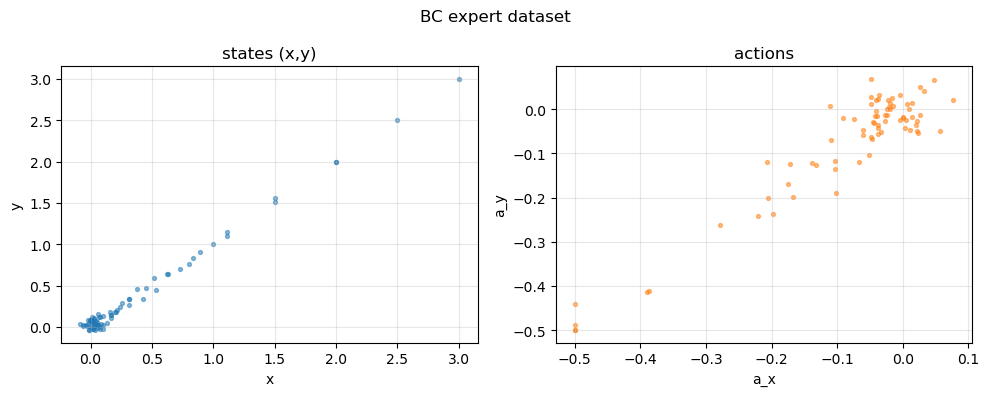

In [2]:
bc_starts = [(1.0, 1.0), (2.0, 2.0), (3.0, 3.0)]
X_bc, Y_bc = il.generate_bc_training_data(
    start_points=bc_starts,
    horizon=25,
)
print('BC dataset:', X_bc.shape, Y_bc.shape)
il.plot_expert_state_action_data(X_bc, Y_bc, title='BC expert dataset')

## 2) 간단한 BC 모델 학습

In [3]:
bc_model = il.train_bc_model(X_bc, Y_bc, epochs=500, lr=1e-3)

[BC epoch 0001] mse=0.017844
[BC epoch 0100] mse=0.000963
[BC epoch 0200] mse=0.000934
[BC epoch 0300] mse=0.000920
[BC epoch 0400] mse=0.000904
[BC epoch 0500] mse=0.000891


## 3) BC 모델 추론 + 시각화 (일반 테스트)

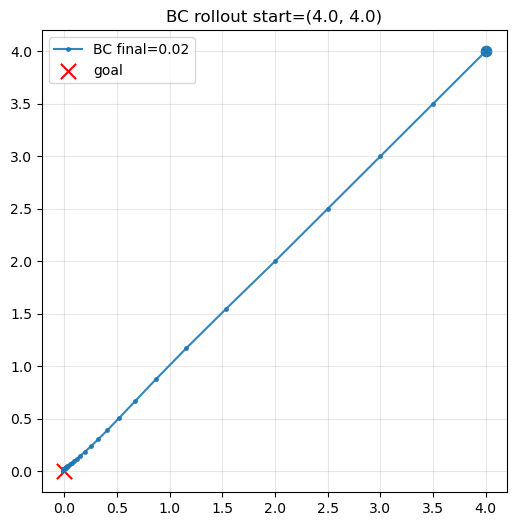

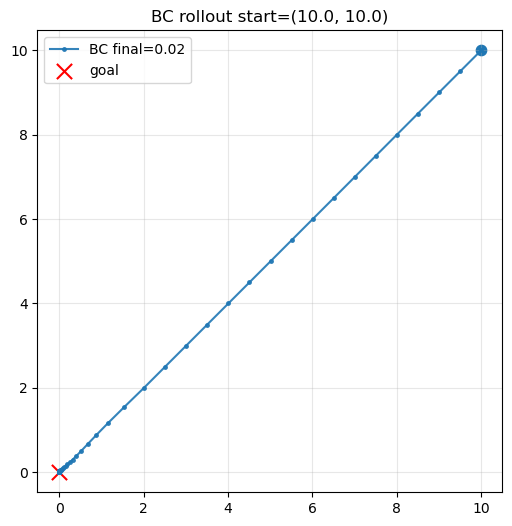

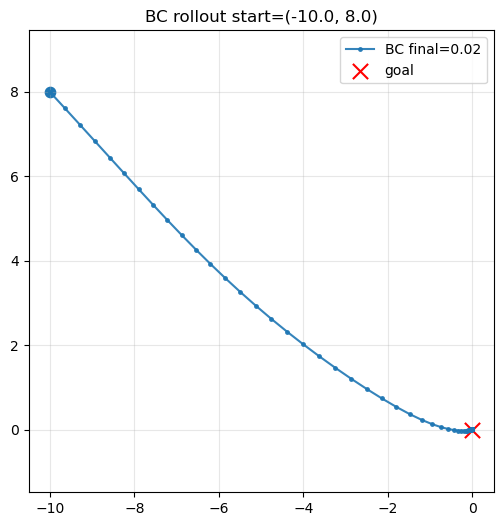

In [4]:
bc_tests = il.get_bc_test_starts()
for st in bc_tests:
    traj = il.rollout_bc_policy(bc_model, start=st, horizon=120, drift=(0.0, 0.0))
    d = il.final_distance_to_goal(traj)
    il.plot_trajectories([traj], [f'BC final={d:.2f}'], title=f'BC rollout start={st}')

## 4) BC의 한계: drift 환경에서 추론 시각화

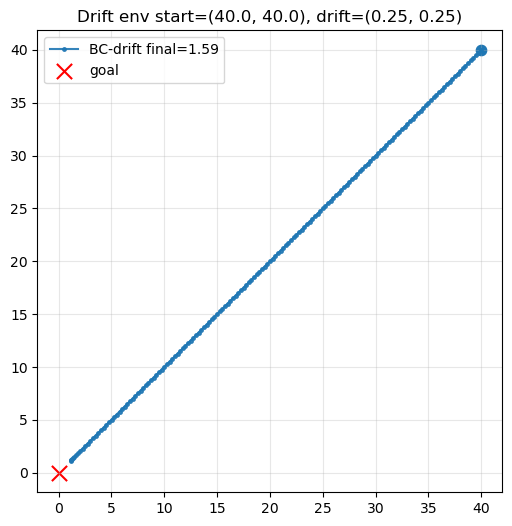

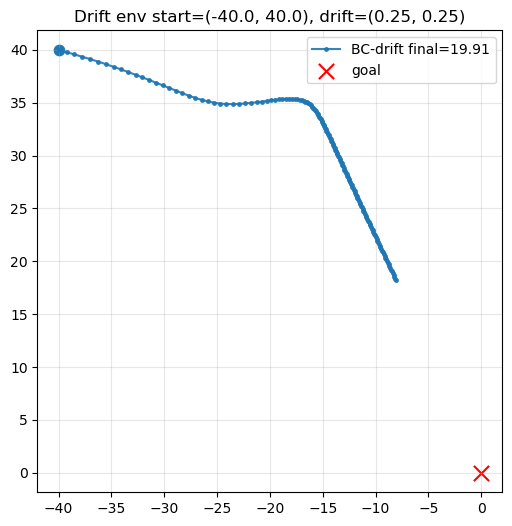

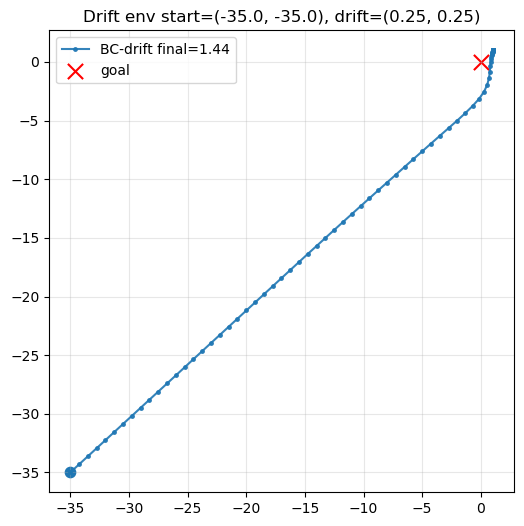

In [5]:
drift = (0.25, 0.25)
hard_tests = il.get_drift_test_starts()
for st in hard_tests:
    traj = il.rollout_bc_policy(bc_model, start=st, horizon=160, drift=drift)
    d = il.final_distance_to_goal(traj)
    il.plot_trajectories([traj], [f'BC-drift final={d:.2f}'], title=f'Drift env start={st}, drift={drift}')

## 5) DAgger 모델 학습

In [6]:
def start_sampler():
    if np.random.rand() < 0.7:
        return (float(np.random.uniform(25, 45)), float(np.random.uniform(25, 45)))
    return (float(np.random.uniform(-10, 10)), float(np.random.uniform(-10, 10)))

bc_base, dagger_model, dagger_hist, _ = il.train_dagger_model(
    X_init=X_bc,
    Y_init=Y_bc,
    start_sampler=start_sampler,
    dagger_iters=6,
    rollouts_per_iter=8,
    rollout_horizon=120,
    drift=drift,
    pretrain_epochs=400,
    finetune_epochs=220,
)
print('DAgger history:', dagger_hist)


=== Train BC baseline ===
[BC epoch 0001] mse=0.037091
[BC epoch 0200] mse=0.000931
[BC epoch 0400] mse=0.000911

=== DAgger iter 1/6 | agg size=1035 ===
[BC epoch 0001] mse=0.251654
[BC epoch 0125] mse=0.000320


[BC epoch 0220] mse=0.000266
[DAgger eval] start=(40.0, 40.0) final_dist=14.30

=== DAgger iter 2/6 | agg size=1995 ===
[BC epoch 0001] mse=0.543744
[BC epoch 0125] mse=0.000615
[BC epoch 0220] mse=0.000296
[DAgger eval] start=(40.0, 40.0) final_dist=14.59

=== DAgger iter 3/6 | agg size=2955 ===
[BC epoch 0001] mse=0.332362


[BC epoch 0125] mse=0.000683
[BC epoch 0220] mse=0.000469
[DAgger eval] start=(40.0, 40.0) final_dist=14.19

=== DAgger iter 4/6 | agg size=3915 ===
[BC epoch 0001] mse=0.141813


[BC epoch 0125] mse=0.000628
[BC epoch 0220] mse=0.000455
[DAgger eval] start=(40.0, 40.0) final_dist=14.14

=== DAgger iter 5/6 | agg size=4875 ===
[BC epoch 0001] mse=0.375950


[BC epoch 0125] mse=0.000797
[BC epoch 0220] mse=0.000505
[DAgger eval] start=(40.0, 40.0) final_dist=14.29

=== DAgger iter 6/6 | agg size=5835 ===
[BC epoch 0001] mse=0.374491


[BC epoch 0125] mse=0.000713
[BC epoch 0220] mse=0.000437
[DAgger eval] start=(40.0, 40.0) final_dist=14.53
DAgger history: [{'iter': 1.0, 'agg_size': 1035.0, 'probe_dist': 14.29967975616455}, {'iter': 2.0, 'agg_size': 1995.0, 'probe_dist': 14.592921257019043}, {'iter': 3.0, 'agg_size': 2955.0, 'probe_dist': 14.193485260009766}, {'iter': 4.0, 'agg_size': 3915.0, 'probe_dist': 14.142135620117188}, {'iter': 5.0, 'agg_size': 4875.0, 'probe_dist': 14.290505409240723}, {'iter': 6.0, 'agg_size': 5835.0, 'probe_dist': 14.525252342224121}]


## 6) BC vs DAgger 결과 비교 시각화

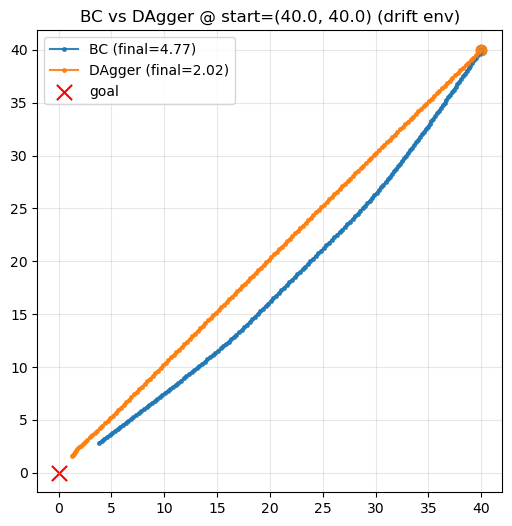

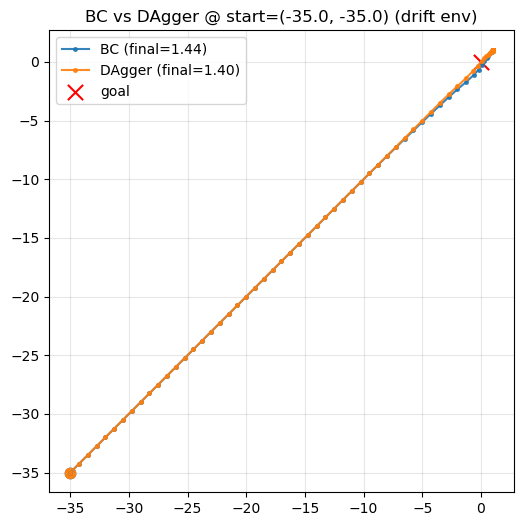

In [7]:
compare_starts = [(40.0, 40.0), (-35.0, -35.0)]
for st in compare_starts:
    traj_bc = il.rollout_bc_policy(bc_base, start=st, horizon=160, drift=drift)
    traj_dg = il.rollout_bc_policy(dagger_model, start=st, horizon=160, drift=drift)
    il.compare_two_policies(
        traj_bc,
        traj_dg,
        label_a='BC',
        label_b='DAgger',
        title=f'BC vs DAgger @ start={st} (drift env)',
    )

## 7) ACT용 데이터(물리+지연관측)에서 BC/DAgger 한계 시각화

ACT expert trajectories: (500, 121, 2) (500, 120, 2)
BC-on-ACT dataset: (60000, 2) (60000, 2)
[BC-on-ACT epoch 001] mse=0.001370


[BC-on-ACT epoch 005] mse=0.000847


[BC-on-ACT epoch 010] mse=0.000830


[BC-on-ACT epoch 015] mse=0.000838


[BC-on-ACT epoch 020] mse=0.000819


[BC-on-ACT epoch 025] mse=0.000815


[BC-on-ACT epoch 030] mse=0.000811


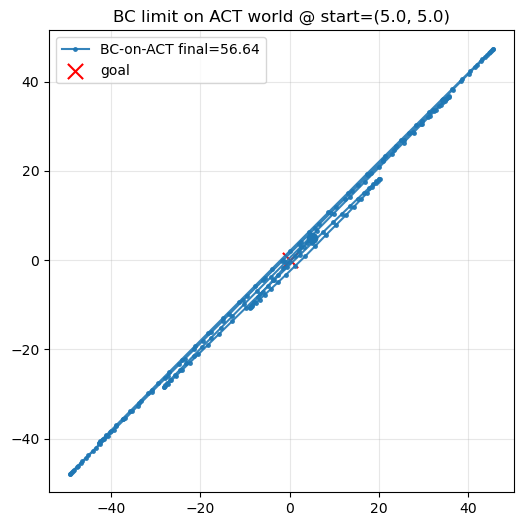

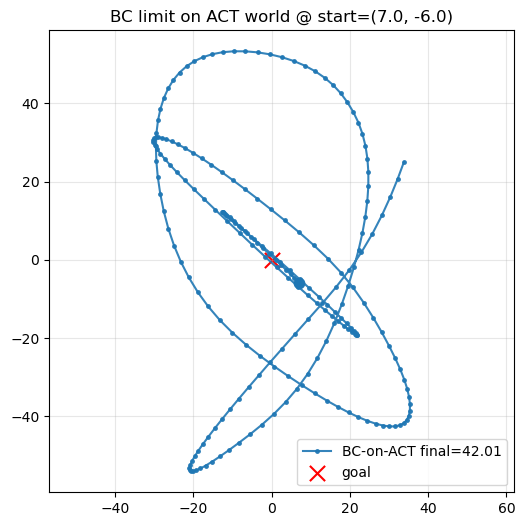

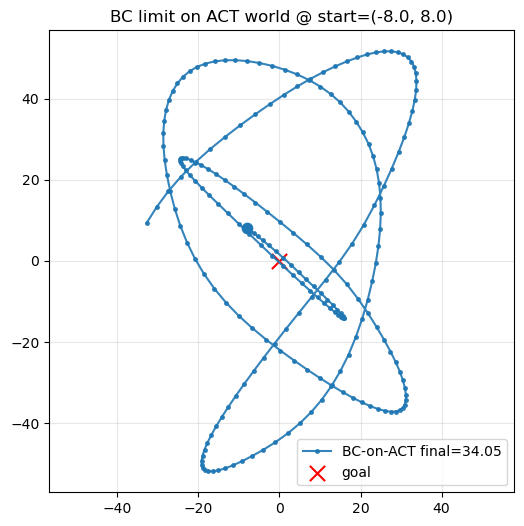

In [8]:
act_world = il.ACTWorldConfig(
    dt=1.0, friction=0.02, accel_clip=0.25,
    drift_x=0.05, drift_y=0.05, obs_delay=3, obs_noise_std=0.02
)
obs_xy, acts_a = il.generate_act_expert_trajectories(
    n_episodes=500, horizon=120, start_range=(-5.0, 5.0), world=act_world
)
print('ACT expert trajectories:', obs_xy.shape, acts_a.shape)

X_bc_act, Y_bc_act = il.build_bc_dataset_delayed(
    obs_xy, acts_a, obs_delay=act_world.obs_delay, obs_noise_std=0.0
)
print('BC-on-ACT dataset:', X_bc_act.shape, Y_bc_act.shape)

bc_on_act = il.train_regression_model(
    il.BCPolicy(), X_bc_act, Y_bc_act, epochs=30, lr=3e-4, tag='BC-on-ACT'
)

for st in il.get_act_test_starts():
    traj = il.rollout_bc_on_act_world(bc_on_act, start_xy=st, steps=220, world=act_world)
    d = il.final_distance_to_goal(traj)
    il.plot_trajectories([traj], [f'BC-on-ACT final={d:.2f}'], title=f'BC limit on ACT world @ start={st}')

## 8) ACT 모델 학습 시작

In [9]:
H, K = 20, 5
X_act, Y_act = il.build_act_dataset_delayed(
    obs_xy, acts_a, history_len=H, chunk_len=K,
    obs_delay=act_world.obs_delay, obs_noise_std=act_world.obs_noise_std
)
print('ACT dataset:', X_act.shape, Y_act.shape)

act_model = il.train_regression_model(
    il.ACTPolicy(history_len=H, chunk_len=K),
    X_act, Y_act,
    epochs=35, lr=3e-4, tag='ACT'
)

ACT dataset: (58000, 20, 2) (58000, 5, 2)


[ACT epoch 001] mse=0.001423


[ACT epoch 005] mse=0.000371


[ACT epoch 010] mse=0.000275


[ACT epoch 015] mse=0.000207


[ACT epoch 020] mse=0.000192


[ACT epoch 025] mse=0.000185


[ACT epoch 030] mse=0.000181


[ACT epoch 035] mse=0.000181


## 9) ACT 모델 추론 시각화 (BC와 비교)

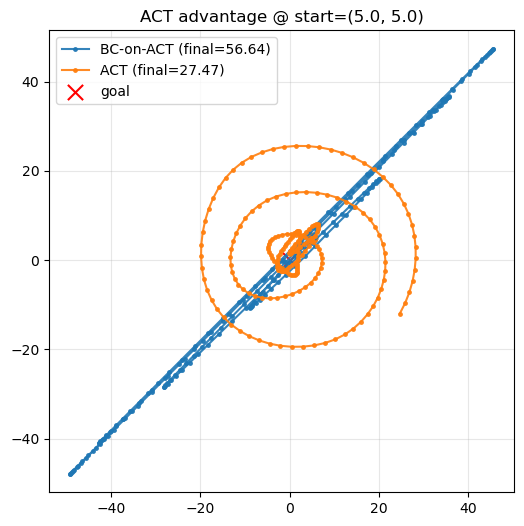

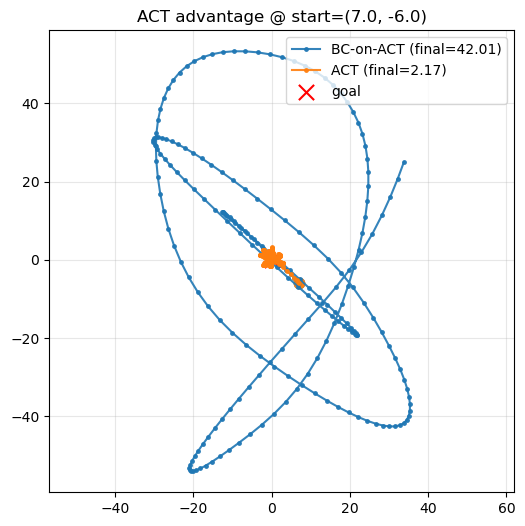

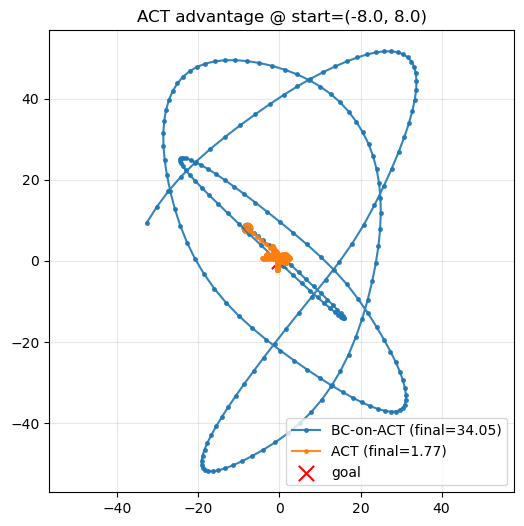

In [10]:
for st in il.get_act_test_starts():
    traj_bc = il.rollout_bc_on_act_world(bc_on_act, start_xy=st, steps=220, world=act_world)
    traj_act = il.rollout_act_policy(act_model, start_xy=st, steps=220, history_len=H, world=act_world)
    il.compare_two_policies(
        traj_bc, traj_act,
        label_a='BC-on-ACT', label_b='ACT',
        title=f'ACT advantage @ start={st}'
    )